In [1]:
# CAS_preprocess_02_py
# using this notebook to execute the .py script while developing in the cloud

## Setup

### Dependencies

In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from PIL import Image
from pathlib import Path
# from config import load_config
import argparse
from datetime import datetime as dt
import h5py
import ast
import CAS_preprocess_02_pixel_to_nm as pixel_to_nm


%matplotlib inline

### Constants

In [3]:
# Lasers used for calibration
lasers = np.array([0.561, 0.514, 0.473, 0.448, 0.405])

# Physical constants
SELLMEIER_COEFFS = (1.73759695, 0.313747356, 1.89878101)
SELLMEIER_TERMS = (0.013188707, 0.0623068142, 155.23629)
THETA_I = 60.8  # angle of incidence (degrees)
ALPHA = 60      # prism apex angle (degrees)

## Functions

In [4]:
# # Refractive index + angle of deviation helper functions
# def sellmeier_index(wavelength):
#     """Compute refractive index (n) from wavelength in microns."""
#     B1, B2, B3 = SELLMEIER_COEFFS
#     C1, C2, C3 = SELLMEIER_TERMS
#     wav2 = wavelength**2
#     return np.sqrt(1 + (B1*wav2)/(wav2 - C1) + (B2*wav2)/(wav2 - C2) + (B3*wav2)/(wav2 - C3))

# def deviation_angle(wavelength, theta_i=THETA_I, alpha=ALPHA):
#     """Compute deviation angle for a given wavelength."""
#     n = sellmeier_index(wavelength)
#     term = (np.sin(np.deg2rad(alpha)) * np.sqrt(n**2 - np.sin(np.deg2rad(theta_i))**2)
#             - np.sin(np.deg2rad(theta_i)) * np.cos(np.deg2rad(alpha)))
#     return theta_i - alpha + np.rad2deg(np.arcsin(term))

# def linear_wave(x, a, b):
#     """Linear fit function between deviation angle and pixel value."""
#     return a * x + b


# # Calibration image helper function
# def find_laser_pixels(image_path, height_thresh=4000, dist_thresh=100):
#     """Find x-pixel positions of laser peaks in calibration image."""
#     I = Image.open(image_path)
#     im = np.array(I)
#     im_line = np.mean(im, axis=0)
#     peaks, _ = find_peaks(im_line, height=height_thresh, distance=dist_thresh)
    
#     plt.figure(figsize=(6,2))
#     plt.plot(im_line)
#     plt.plot(peaks, im_line[peaks], 'x')
#     plt.title('Laser Peaks in Calibration Image')
#     plt.show()
    
#     return peaks


# # Calibration fitting function
# def fit_wavelength_to_pixels(lasers, pixel_positions):
#     """Fit wavelength-pixel relationship using linear model."""
#     theta_D = deviation_angle(lasers)
#     popt, _ = curve_fit(linear_wave, theta_D, pixel_positions)
#     return popt, theta_D


# # LUT building function
# def generate_lut(popt, calib_file, wavelength_range=(0.4, 0.7, 0.001)):
#     wavelength = np.arange(*wavelength_range)
#     theta_D = deviation_angle(wavelength)
#     pixel_value = linear_wave(theta_D, *popt)

#     # Safe parsing of calibration.txt
#     calib_dict = {}
#     with open(calib_file, 'r') as f:
#         for line in f:
#             name, value = line.strip().split(' = ')
#             calib_dict[name] = ast.literal_eval(value)  # Safe conversion

#     pixel_value_new = calib_dict['calib_Xoffset'] + np.round(pixel_value).astype(int)
#     return pd.DataFrame({'Camera_pixel': pixel_value_new, 'Wavelength_nm': (1000*wavelength).astype(int)})



# # Plotting function
# def plot_calibration_results(lasers, laser_pix, wavelength, pixel_value):
#     """Plot calibration fit and deviation angle mapping."""
#     plt.figure(figsize=(8,3))
#     plt.plot(pixel_value, 1000*wavelength, 'b-', label='Fitted Curve')
#     plt.plot(laser_pix, 1000*lasers, 'ro', label='Measured Lasers')
#     plt.xlabel('Camera pixel')
#     plt.ylabel('Wavelength (nm)')
#     plt.legend()
#     plt.show()


## Main

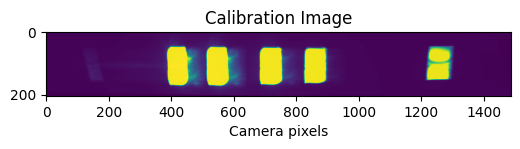

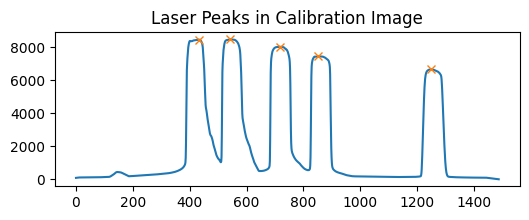

Fit parameters: a=89.5788, b=-5592.3758


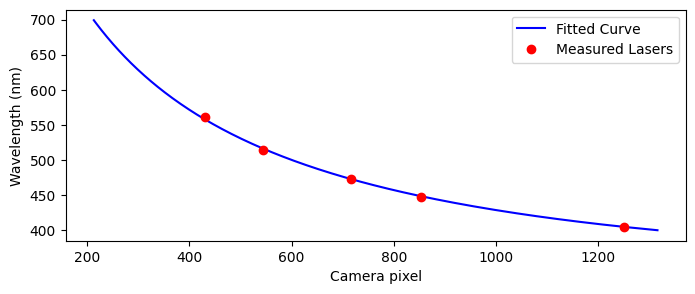

   Camera_pixel  Wavelength_nm
0          1664            400
1          1649            401
2          1635            402
3          1622            403
4          1608            404
HDF5 keys: ['Camera_pixel', 'Wavelength_nm']


In [5]:
parser = argparse.ArgumentParser(
    description="Calibrate prism dispersion and generate wavelength-to-pixel LUT"
)
parser.add_argument(
    "--results_dir",
    type=str,
    default="/results/",
    help="Directory containing the calibration image and calibration.txt file",
)
args = parser.parse_args(args=[]) # added args=[] for compatibility with Jupyter notebook
results_dir = Path(args.results_dir)

calib_image = results_dir / 'CalibrationImage.tiff'
calib_file = results_dir / 'calibration.txt'

laser_pix = pixel_to_nm.find_laser_pixels(calib_image)

popt, theta_D = pixel_to_nm.fit_wavelength_to_pixels(lasers, laser_pix)
print(f"Fit parameters: a={popt[0]:.4f}, b={popt[1]:.4f}")

wavelength = np.arange(0.4, 0.7, 0.001)
pixel_value = pixel_to_nm.linear_wave(pixel_to_nm.deviation_angle(wavelength), *popt)
pixel_to_nm.plot_calibration_results(lasers, laser_pix, wavelength, pixel_value)

lut, pixel_value_wave, theta_D_wave = pixel_to_nm.generate_lut(popt, calib_file)
print(lut.head())

hdf5_file = results_dir / 'pixel_to_nm.hdf5'
store = pd.HDFStore(hdf5_file, mode='a')
for col in lut.columns:
    lut[col].to_hdf(store, key=col, mode='a')
store.close()

with h5py.File(hdf5_file, 'r') as f:
    print("HDF5 keys:", list(f.keys()))

In [6]:
print(lut)

     Camera_pixel  Wavelength_nm
0            1664            400
1            1649            401
2            1635            402
3            1622            403
4            1608            404
..            ...            ...
295           565            695
296           564            696
297           563            697
298           562            698
299           561            699

[300 rows x 2 columns]


## Plots

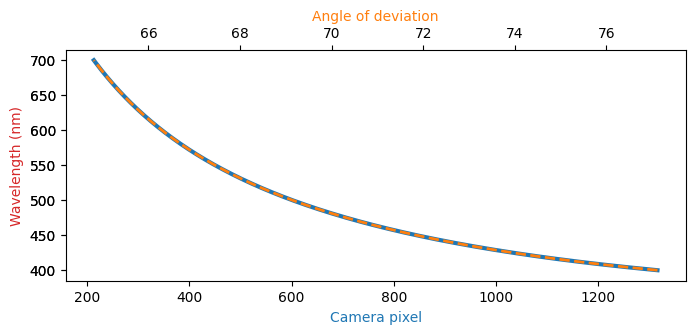

In [7]:
fig = plt.figure(figsize=(8,3))
ax1 = fig.add_subplot(111, label='1')
ax1.plot(pixel_value_wave, 1000*wavelength, color='C0', linewidth=3)
ax1.set_xlabel('Camera pixel', color='C0')
ax1.set_ylabel('Wavelength (nm)', color='C3')
ax2 = fig.add_subplot(111, label='2', frame_on=False)
ax2.plot(theta_D_wave, 1000*wavelength, '--', color='C1', linewidth=2)
ax2.xaxis.tick_top()
ax2.set_xlabel('Angle of deviation', color='C1')
ax2.xaxis.set_label_position('top') 
plt.show()

## Compare script output with Smrithi's output
Will report any differences between the file generated in this script and the original file generated by Smrithi's code.

In [8]:
# Check that generated .hdf5 matches Smrithi's original file
import filecmp
h5py_original = "/data/HSFP_775510_2025-02-20_11-08-27/fib/pixel_to_nm.hdf5"
h5py_new = hdf5_file

In [9]:
def compare_hdf5_file_metadata(file1, file2):
    """Compare HDF5 file-level metadata (attributes and creation properties)."""
    with h5py.File(file1, 'r') as f1, h5py.File(file2, 'r') as f2:
        print(f"\nComparing file-level metadata for:\n  {file1}\n  {file2}\n")

        # File-level attributes
        attrs1 = dict(f1.attrs)
        attrs2 = dict(f2.attrs)
        if attrs1 != attrs2:
            print("⚠️ File-level attributes differ:")
            print("  File 1 attrs:", attrs1)
            print("  File 2 attrs:", attrs2)
        else:
            print("✅ File-level attributes identical.")

        # File creation property lists (basic comparison)
        fcpl1 = f1.id.get_create_plist()
        fcpl2 = f2.id.get_create_plist()

        userblock1 = fcpl1.get_userblock()
        userblock2 = fcpl2.get_userblock()
        if userblock1 != userblock2:
            print("\n⚠️ Userblock sizes differ:")
            print("  File 1:", userblock1)
            print("  File 2:", userblock2)
        else:
            print("\n✅ Userblock sizes identical.")

        # Access property list / driver
        fapl1 = f1.id.get_access_plist()
        fapl2 = f2.id.get_access_plist()
        driver1 = fapl1.get_driver()
        driver2 = fapl2.get_driver()
        if driver1 != driver2:
            print("\n⚠️ Access drivers differ:")
            print("  File 1:", driver1)
            print("  File 2:", driver2)
        else:
            print("\n✅ Access drivers identical.")

    print("\n🔍 Metadata comparison complete.\n")


In [10]:
compare_hdf5_file_metadata(h5py_original, h5py_new)


Comparing file-level metadata for:
  /data/HSFP_775510_2025-02-20_11-08-27/fib/pixel_to_nm.hdf5
  /results/pixel_to_nm.hdf5

✅ File-level attributes identical.

✅ Userblock sizes identical.

✅ Access drivers identical.

🔍 Metadata comparison complete.



In [11]:
def compare_hdf5_bytes(file1, file2, chunk_size=1024):
    """Compare two HDF5 files byte by byte to find where they differ."""
    diff_positions = []
    with open(file1, 'rb') as f1, open(file2, 'rb') as f2:
        pos = 0
        while True:
            b1 = f1.read(chunk_size)
            b2 = f2.read(chunk_size)
            if not b1 and not b2:
                break  # reached EOF for both
            if b1 != b2:
                # find exact byte offsets that differ
                for i, (x, y) in enumerate(zip(b1, b2)):
                    if x != y:
                        diff_positions.append(pos + i)
            pos += chunk_size

    if diff_positions:
        print(f"⚠️ Files differ at {len(diff_positions)} byte positions.")
        print("First few differences (byte offsets):", diff_positions[:20])
    else:
        print("✅ Files are byte-for-byte identical.")

In [12]:
compare_hdf5_bytes(h5py_original, h5py_new)

⚠️ Files differ at 3606 byte positions.
First few differences (byte offsets): [40, 41, 1026, 1048, 1049, 1056, 1057, 1096, 1097, 1608, 1609, 1610, 1611, 1616, 1617, 1624, 1625, 1632, 1633, 1634]


In [13]:
def compare_hdf5_recursive(file1, file2, max_diffs=10):
    """Recursively compare datasets and groups in two HDF5 files and show differing indices."""

    def _compare_items(obj1, obj2, path="/"):
        # Check datasets
        if isinstance(obj1, h5py.Dataset) and isinstance(obj2, h5py.Dataset):
            data1 = obj1[()]
            data2 = obj2[()]
            if not np.array_equal(data1, data2):
                diff = np.abs(data1 - data2)
                diff_indices = np.where(data1 != data2)
                num_diffs = len(diff_indices[0]) if diff_indices else 0

                print(f"❌ Dataset {path} differs")
                print(f"   Shape: {data1.shape}, Max diff: {np.max(diff)}, Min diff: {np.min(diff)}")
                print(f"   Number of differing elements: {num_diffs}")

                # Show up to `max_diffs` examples of where they differ
                print("   Example differing indices and values:")
                for i in range(min(max_diffs, num_diffs)):
                    idx = diff_indices[0][i] if diff_indices[0].size > 0 else None
                    if idx is not None:
                        print(f"     Index {idx}: file1={data1[idx]}, file2={data2[idx]}")
            else:
                print(f"✅ Dataset {path} identical")

        # Check groups
        elif isinstance(obj1, h5py.Group) and isinstance(obj2, h5py.Group):
            keys1 = set(obj1.keys())
            keys2 = set(obj2.keys())
            # Items missing in either file
            for key in keys1 - keys2:
                print(f"❌ {path}{key} missing in second file")
            for key in keys2 - keys1:
                print(f"❌ {path}{key} missing in first file")
            # Compare shared keys recursively
            for key in keys1 & keys2:
                _compare_items(obj1[key], obj2[key], path + key + "/")

        else:
            print(f"⚠️ Type mismatch at {path}: {type(obj1)} vs {type(obj2)}")

    # Open both files
    with h5py.File(file1, 'r') as f1, h5py.File(file2, 'r') as f2:
        _compare_items(f1, f2)

In [14]:
compare_hdf5_recursive(h5py_original, h5py_new)

✅ Dataset /Camera_pixel/index/ identical
❌ Dataset /Camera_pixel/values/ differs
   Shape: (300,), Max diff: 1, Min diff: 0
   Number of differing elements: 194
   Example differing indices and values:
     Index 1: file1=1650, file2=1649
     Index 2: file1=1636, file2=1635
     Index 4: file1=1609, file2=1608
     Index 28: file1=1353, file2=1354
     Index 30: file1=1336, file2=1337
     Index 36: file1=1288, file2=1289
     Index 38: file1=1273, file2=1274
     Index 41: file1=1251, file2=1252
     Index 42: file1=1244, file2=1245
     Index 43: file1=1237, file2=1238
✅ Dataset /Wavelength_nm/index/ identical
✅ Dataset /Wavelength_nm/values/ identical
